In [15]:
!pip install tensorflow numpy matplotlib scikit-learn seaborn pillow opencv-python flask

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "PlantVillage",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "PlantVillage",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 33027 images belonging to 16 classes.
Found 8249 images belonging to 16 classes.


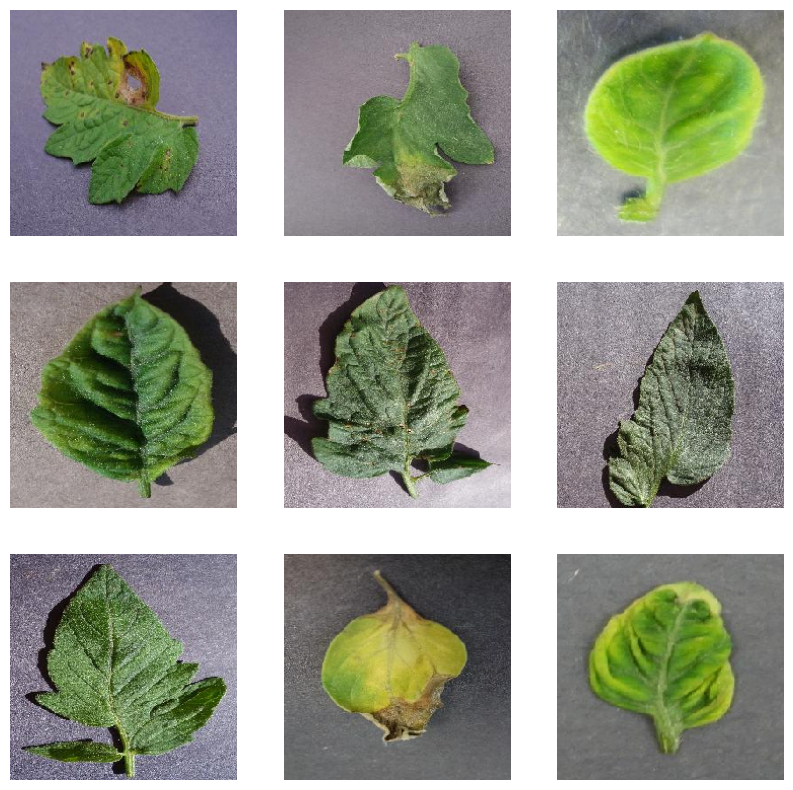

In [18]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [20]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [21]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

In [22]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3
)

In [24]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 2071s 2s/step - accuracy: 0.5285 - loss: 1.0866 - val_accuracy: 0.1679 - val_loss: 4.0742
Epoch 2/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1495s 1s/step - accuracy: 0.5442 - loss: 0.8342 - val_accuracy: 0.1600 - val_loss: 5.1128
Epoch 3/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1477s 1s/step - accuracy: 0.5562 - loss: 0.7615 - val_accuracy: 0.1679 - val_loss: 6.2030
Epoch 4/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1598s 2s/step - accuracy: 0.5595 - loss: 0.7272 - val_accuracy: 0.1343 - val_loss: 6.7893


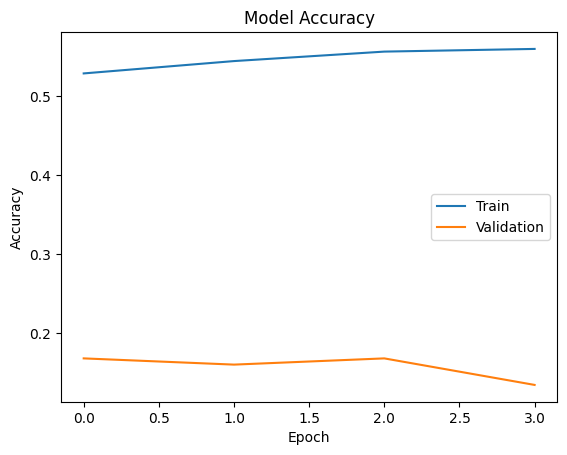

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

In [27]:
model.evaluate(val_data)

258/258 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.1343 - loss: 6.7893


[6.7892746925354, 0.13431930541992188]

In [28]:
model.save("plant_disease_model.h5")

print("Model saved successfully")

Model saved successfully
